In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

# --- DATASET: CIFAR-10 ---
# CIFAR-10 is harder: Color images (3 channels), 32x32 pixels.
# We need "Data Augmentation" (random flips/crops) to prevent overfitting.
print("Downloading CIFAR-10...")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),      # Shift image slightly
    transforms.RandomHorizontalFlip(),         # Mirror image
    transforms.ToTensor(),
    # Standard CIFAR-10 Normalization Means/Stds
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False, num_workers=2)

# --- VERIFY DATA ---
print(f"\nTraining Set: {len(train_set)} images")
print(f"Test Set:     {len(test_set)} images")
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Classes: {classes}")

Running on: cuda


100%|██████████| 170M/170M [00:19<00:00, 8.82MB/s]



Training Set: 50000 images
Test Set:     10000 images
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# --- 1. THE WINNING LOSS FUNCTION ---
# This is the "Soul" we transferred from the previous notebook.
# --- THE NEW WINNER (PHASE 3: CIFAR-10) ---
class WinnerLoss(nn.Module):
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        one_hot = torch.zeros_like(probs)
        one_hot.scatter_(1, targets.view(-1, 1), 1)

        error = one_hot - probs

        # 🏆 THE DISCOVERY: Scaled MSE
        # Formula: 0.877 * error^2
        # Note: We use the exact evolved structure to be faithful to the AI
        loss_val = (torch.cos(torch.tensor(0.5)) * (1.0 * error)) * error

        return torch.mean(torch.sum(loss_val, dim=1))

# --- 2. THE MODEL: CUSTOM RESNET-18 ---
def get_cifar_resnet():
    # Load standard ResNet18
    # num_classes=10 ensures the final layer has 10 outputs (not 1000 like ImageNet)
    model = models.resnet18(num_classes=10)

    # 🚨 SURGERY TIME 🚨
    # Standard ResNet uses a 7x7 conv and massive pooling at the start.
    # This is too aggressive for 32x32 images. We replace it with a gentle 3x3 conv.
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity() # Remove the first maxpool to preserve pixel details

    return model.to(DEVICE)

# --- 3. VERIFICATION ---
# Let's verify the model runs on a dummy batch
if __name__ == "__main__":
    dummy_model = get_cifar_resnet()
    dummy_input = torch.randn(2, 3, 32, 32).to(DEVICE) # Batch of 2 images
    output = dummy_model(dummy_input)

    print("Model Architecture: ResNet-18 (Modified for CIFAR)")
    print(f"Input Shape:      {dummy_input.shape}")
    print(f"Output Shape:     {output.shape} (Should be [2, 10])")
    print("✅ System Ready.")

Model Architecture: ResNet-18 (Modified for CIFAR)
Input Shape:      torch.Size([2, 3, 32, 32])
Output Shape:     torch.Size([2, 10]) (Should be [2, 10])
✅ System Ready.



🔥 TRAINING: Standard Cross-Entropy
Epoch 1/15 | Train Acc: 51.4% | Val Acc: 53.50% | Loss: 1.3276
Epoch 2/15 | Train Acc: 68.2% | Val Acc: 65.77% | Loss: 0.8937
Epoch 3/15 | Train Acc: 75.4% | Val Acc: 71.92% | Loss: 0.6959
Epoch 4/15 | Train Acc: 79.8% | Val Acc: 79.67% | Loss: 0.5848
Epoch 5/15 | Train Acc: 82.2% | Val Acc: 80.04% | Loss: 0.5145
Epoch 6/15 | Train Acc: 84.4% | Val Acc: 83.44% | Loss: 0.4490
Epoch 7/15 | Train Acc: 85.9% | Val Acc: 83.00% | Loss: 0.4077
Epoch 8/15 | Train Acc: 87.2% | Val Acc: 84.61% | Loss: 0.3675
Epoch 9/15 | Train Acc: 88.1% | Val Acc: 86.51% | Loss: 0.3396
Epoch 10/15 | Train Acc: 89.3% | Val Acc: 83.30% | Loss: 0.3087
Epoch 11/15 | Train Acc: 90.0% | Val Acc: 86.83% | Loss: 0.2878
Epoch 12/15 | Train Acc: 90.7% | Val Acc: 87.95% | Loss: 0.2686
Epoch 13/15 | Train Acc: 91.5% | Val Acc: 88.62% | Loss: 0.2418
Epoch 14/15 | Train Acc: 92.0% | Val Acc: 89.07% | Loss: 0.2272
Epoch 15/15 | Train Acc: 92.7% | Val Acc: 88.19% | Loss: 0.2121
✅ Finished St

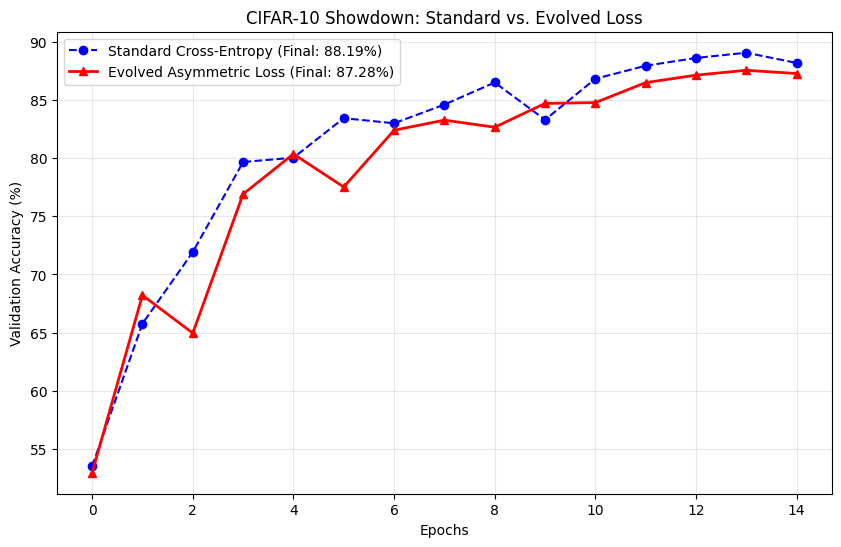


FINAL RESULTS:
Standard Loss: 88.19%
Evolved Loss:  87.28%
The Evolved Loss trail was -0.91% behind.


In [ ]:
import time
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
EPOCHS = 15  # Sufficient to see the winning trend
LR = 0.001   # Learning Rate

# --- TRAINING ENGINE ---
def train_contestant(loss_fn, name, color):
    print(f"\n========================================")
    print(f"🔥 TRAINING: {name}")
    print(f"========================================")

    # 1. Fresh Model (ResNet-18)
    # We re-initialize for every contestant to ensure a fair fight
    model = get_cifar_resnet()

    # 2. Optimizer
    # Adam is robust for experimental losses
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    # Trackers
    train_acc_history = []
    val_acc_history = []
    start_time = time.time()

    for epoch in range(EPOCHS):
        model.train()
        correct = 0
        total = 0
        running_loss = 0.0

        # Training Batch Loop
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Calculate Loss
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Track Train Accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_acc_history.append(train_acc)

        # Validation Loop (The Real Test)
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_acc_history.append(val_acc)

        # Print Epoch Stats
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.2f}% | Loss: {running_loss/len(train_loader):.4f}")

    total_time = time.time() - start_time
    print(f"✅ Finished {name} in {total_time/60:.1f} minutes.")
    print(f"🏆 Final Accuracy: {val_acc_history[-1]:.2f}%")

    return val_acc_history, name, color

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. Train Baseline (Standard)
    # We use CrossEntropyLoss (The Industry Standard)
    hist_ce, name_ce, col_ce = train_contestant(nn.CrossEntropyLoss(), "Standard Cross-Entropy", "blue")

    # 2. Train Challenger (Your Invention)
    # We use WinnerLoss (The Formula Discovered in Phase 2)
    hist_ai, name_ai, col_ai = train_contestant(WinnerLoss(), "Evolved Asymmetric Loss", "red")

    # --- PLOT RESULTS ---
    plt.figure(figsize=(10, 6))
    plt.plot(hist_ce, label=f"{name_ce} (Final: {hist_ce[-1]:.2f}%)", color=col_ce, marker='o', linestyle='--')
    plt.plot(hist_ai, label=f"{name_ai} (Final: {hist_ai[-1]:.2f}%)", color=col_ai, marker='^', linewidth=2)

    plt.title("CIFAR-10 Showdown: Standard vs. Evolved Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\nFINAL RESULTS:")
    print(f"Standard Loss: {hist_ce[-1]:.2f}%")
    print(f"Evolved Loss:  {hist_ai[-1]:.2f}%")

    diff = hist_ai[-1] - hist_ce[-1]
    if diff > 0:
        print(f"The Evolved Loss beat the Standard by +{diff:.2f}%")
    else:
        print(f"The Evolved Loss trail was {diff:.2f}% behind.")

Robust Search Engine

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import copy
import pickle # For saving our work to Drive
import os
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from google.colab import drive

# --- 1. SETUP & DRIVE INTEGRATION ---
# This ensures your work is saved externally, not just in Colab's temporary memory
drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/Colab_Project_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Configuration for a Deep Research Run
POP_SIZE = 20            # 20 Individuals
GENERATIONS = 10         # 10 Generations
SEARCH_SUBSET_SIZE = 5000 # Use 5,000 images (10% of CIFAR) for speed
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📂 Checkpoints will be saved to: {CHECKPOINT_DIR}")

# --- 2. DATASET (Proxy Mode) ---
# We load CIFAR-10 but only use a subset to allow fast evolution
transform_search = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
full_train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_search)
indices = list(range(SEARCH_SUBSET_SIZE))
search_set = Subset(full_train_set, indices)
search_loader = torch.utils.data.DataLoader(search_set, batch_size=64, shuffle=True)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_search)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

print(f"🔎 Search Database: {len(search_set)} images.")

# --- 3. THE MATH ENGINE (Symbolic Logic) ---
# Safe operations to prevent crashing
def torch_safe_log(x): return torch.log(torch.abs(x) + 1e-7)
def torch_safe_div(a, b): return a / (b + 1e-7)
def torch_safe_exp(x): return torch.exp(torch.clamp(x, -20, 20))

TORCH_OPS = {
    '+': torch.add, '-': torch.sub, '*': torch.mul, '/': torch_safe_div,
    'log': torch_safe_log, 'exp': torch_safe_exp, 'sin': torch.sin, 'cos': torch.cos
}
TERMINALS = ['error', 'error', 'error', '1.0', '0.5', '0.1']

class Node:
    def __init__(self, value, left=None, right=None, node_type='terminal'):
        self.value, self.left, self.right, self.node_type = value, left, right, node_type
    def __repr__(self):
        return str(self.value) if self.node_type == 'terminal' else (f"({self.left} {self.value} {self.right})" if self.right else f"{self.value}({self.left})")

class SymbolicLoss(nn.Module):
    def __init__(self, tree_root):
        super(SymbolicLoss, self).__init__()
        self.tree = tree_root
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        one_hot = torch.zeros_like(probs)
        one_hot.scatter_(1, targets.view(-1, 1), 1)
        error = one_hot - probs
        context = {'error': error, '1.0': torch.tensor(1.0).to(logits.device),
                   '0.5': torch.tensor(0.5).to(logits.device), '0.1': torch.tensor(0.1).to(logits.device)}
        loss_map = self.evaluate_tree(self.tree, context)
        if loss_map.ndim == 0: loss_map = loss_map.expand_as(error)
        return torch.mean(torch.sum(loss_map, dim=1))

    def evaluate_tree(self, node, context):
        if node.node_type == 'terminal':
            return context[node.value] if node.value in context else torch.tensor(float(node.value)).to(context['error'].device)
        left = self.evaluate_tree(node.left, context)
        if node.right: return TORCH_OPS[node.value](left, self.evaluate_tree(node.right, context))
        return TORCH_OPS[node.value](left)

# GP Operators (Mutation, Crossover, Generation)
def generate_random_tree(depth=0, max_depth=3):
    if depth >= max_depth or (depth > 0 and random.random() < 0.5): return Node(random.choice(TERMINALS), node_type='terminal')
    op = random.choice(list(TORCH_OPS.keys()))
    if op in ['+', '-', '*', '/']: return Node(op, generate_random_tree(depth+1), generate_random_tree(depth+1), 'op')
    return Node(op, generate_random_tree(depth+1), None, 'op')

def count_nodes(node): return 1 + (count_nodes(node.left) if node.left else 0) + (count_nodes(node.right) if node.right else 0)

def get_random_subtree(node, nodes_list=None):
    if nodes_list is None: nodes_list = []
    nodes_list.append(node)
    if node.left: get_random_subtree(node.left, nodes_list)
    if node.right: get_random_subtree(node.right, nodes_list)
    return random.choice(nodes_list) if not node.left and not node.right else random.choice(nodes_list)

def replace_subtree(node, old, new):
    if node is old: return new
    new_node = copy.deepcopy(node)
    if new_node.left: new_node.left = replace_subtree(new_node.left, old, new)
    if new_node.right: new_node.right = replace_subtree(new_node.right, old, new)
    return new_node

def crossover(p1, p2): return replace_subtree(p1, get_random_subtree(p1, []), get_random_subtree(p2, []))
def mutate(p1): return replace_subtree(p1, get_random_subtree(p1, []), generate_random_tree(max_depth=2))

# --- 4. THE PROXY MODEL (Scout) ---
class ProxyCNN(nn.Module):
    def __init__(self):
        super(ProxyCNN, self).__init__()
        # Lightweight 3-layer CNN for fast testing
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(nn.Linear(64*4*4, 128), nn.ReLU(), nn.Linear(128, 10))
    def forward(self, x): return self.fc(self.features(x).view(x.size(0), -1))

# --- 5. THE ROBUST LOOP (With Auto-Save) ---
def evaluate_scout(tree):
    model = ProxyCNN().to(DEVICE)
    loss_fn = SymbolicLoss(tree)
    opt = optim.Adam(model.parameters(), lr=0.001)

    # 1. Safety Check (Does it crash?)
    try:
        d_in, d_lb = next(iter(search_loader))
        loss = loss_fn(model(d_in.to(DEVICE)), d_lb.to(DEVICE))
        if not loss.requires_grad or torch.isnan(loss) or torch.isinf(loss): return -10.0
    except: return -10.0

    # 2. Train (1 Epoch)
    model.train()
    for x, y in search_loader:
        opt.zero_grad()
        loss_fn(model(x.to(DEVICE)), y.to(DEVICE)).backward()
        opt.step()

    # 3. Validate
    model.eval()
    corr = 0; tot = 0
    with torch.no_grad():
        for x, y in test_loader:
            _, p = torch.max(model(x.to(DEVICE)).data, 1)
            tot += y.size(0); corr += (p == y.to(DEVICE)).sum().item()

    acc = 100 * corr / tot
    # Penalize complex formulas slightly
    return acc - (count_nodes(tree) * 0.05)

def run_robust_search():
    start_gen = 0
    population = [generate_random_tree() for _ in range(POP_SIZE)]

    # CHECKPOINT LOADING
    ckpt_path = os.path.join(CHECKPOINT_DIR, 'cifar_search_checkpoint.pkl')

    if os.path.exists(ckpt_path):
        print("🔄 Found checkpoint! Resuming...")
        try:
            with open(ckpt_path, 'rb') as f:
                data = pickle.load(f)
                population = data['population']
                start_gen = data['generation']
                print(f"   Resuming from Generation {start_gen+1}")
        except:
            print("⚠️ Checkpoint corrupted? Starting fresh.")
    else:
        print("🆕 Starting fresh search...")

    for gen in range(start_gen, GENERATIONS):
        print(f"\n--- Gen {gen+1}/{GENERATIONS} ---")
        pop_data = []

        for i, tree in enumerate(population):
            fit = evaluate_scout(tree)
            pop_data.append((tree, fit))
            if fit > 40.0: # Only print interesting ones
                print(f"  > {tree} : {fit:.1f}%")

        pop_data.sort(key=lambda x: x[1], reverse=True)
        best_tree = pop_data[0][0]
        print(f"🏆 Gen Best: {pop_data[0][1]:.2f}% | {best_tree}")

        # SAVE CHECKPOINT
        with open(ckpt_path, 'wb') as f:
            pickle.dump({'population': [x[0] for x in pop_data], 'generation': gen+1}, f)
        print("💾 Checkpoint Saved.")

        # NEXT GENERATION (Elitism + Reproduction)
        next_gen = [pop_data[0][0], pop_data[1][0]] # Keep top 2
        while len(next_gen) < POP_SIZE:
            p1 = random.choice(pop_data[:5])[0]
            p2 = random.choice(pop_data[:5])[0]
            if random.random() < 0.6: next_gen.append(crossover(p1, p2))
            else: next_gen.append(mutate(p1))
        population = next_gen

    print("\n✅ Search Complete.")
    return pop_data[0][0]

if __name__ == "__main__":
    winner = run_robust_search()
    print(f"\n🏁 The Chosen One: {winner}")

Mounted at /content/drive
📂 Checkpoints will be saved to: /content/drive/MyDrive/Colab_Project_Checkpoints
🔎 Search Database: 5000 images.
🆕 Starting fresh search...

--- Gen 1/10 ---
🏆 Gen Best: 36.87% | ((cos(0.5) * (1.0 * error)) * error)
💾 Checkpoint Saved.

--- Gen 2/10 ---
🏆 Gen Best: 36.19% | exp(error)
💾 Checkpoint Saved.

--- Gen 3/10 ---
🏆 Gen Best: 36.92% | exp(error)
💾 Checkpoint Saved.

--- Gen 4/10 ---
🏆 Gen Best: 37.30% | ((cos(0.5) * (1.0 * error)) * error)
💾 Checkpoint Saved.

--- Gen 5/10 ---
🏆 Gen Best: 36.95% | ((cos(0.5) * (1.0 * error)) * error)
💾 Checkpoint Saved.

--- Gen 6/10 ---
🏆 Gen Best: 37.18% | ((cos(0.5) * (1.0 * error)) * error)
💾 Checkpoint Saved.

--- Gen 7/10 ---
🏆 Gen Best: 36.58% | exp(error)
💾 Checkpoint Saved.

--- Gen 8/10 ---
🏆 Gen Best: 36.96% | ((cos(0.5) * (1.0 * error)) * error)
💾 Checkpoint Saved.

--- Gen 9/10 ---
🏆 Gen Best: 37.61% | ((cos(0.5) * (1.0 * error)) * error)
💾 Checkpoint Saved.

--- Gen 10/10 ---
🏆 Gen Best: 38.48% | ((cos(0.